In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
iris = load_iris()

X = iris.data
y = iris.target

print(X.shape)

(150, 4)


In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
scaler = StandardScaler()# Mean = 0, Standard Deviation = 1

X_scaled = scaler.fit_transform(X)

In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [7]:
print(X_pca.shape)

(150, 2)


In [10]:
print(pca.explained_variance_ratio_) #after reducing from 4 features → 2 features, we still keep about 96% of the information

[0.72962445 0.22850762]


In [11]:
cov_matrix = np.cov(X_scaled.T)#Compute the Covariance Matrix

In [12]:
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)#Compute Eigenvalues & Eigenvectors

In [13]:
sorted_idx = np.argsort(eigen_values)[::-1]# Sort by eigenvalue, descending

eigen_values = eigen_values[sorted_idx]
eigen_vectors = eigen_vectors[:, sorted_idx]

In [14]:
projection_matrix = eigen_vectors[:, :2]

In [15]:
X_manual = X_scaled.dot(projection_matrix)

In [16]:
explained_variance_ratio = eigen_values / np.sum(eigen_values)
print("Explained variance ratio:", explained_variance_ratio)
print("Cumulative variance (2 PCs):", np.sum(explained_variance_ratio[:2]))

Explained variance ratio: [0.72962445 0.22850762 0.03668922 0.00517871]
Cumulative variance (2 PCs): 0.9581320720000165


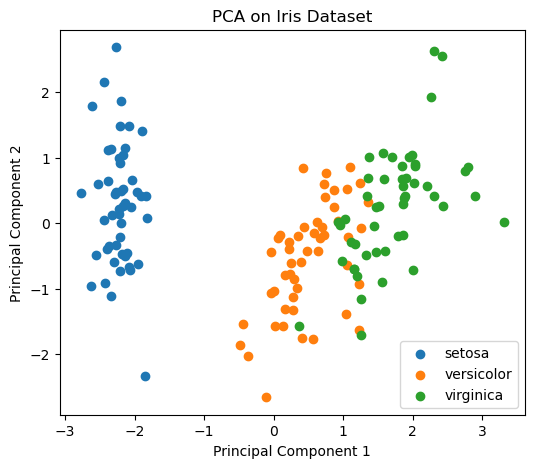

In [17]:
plt.figure(figsize=(6,5))

for i in range(3):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=iris.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA on Iris Dataset")
plt.legend()

plt.show()

In [18]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative Variance:")
print(np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.72962445 0.22850762]

Cumulative Variance:
0.9581320720000164


In [20]:
from mpl_toolkits.mplot3d import Axes3D

In [21]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

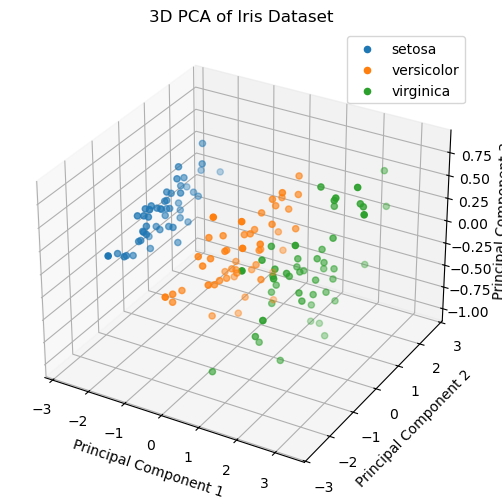

In [22]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')

for i in range(3):
    ax.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        X_pca[y==i,2],
        label=iris.target_names[i]
    )

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.title("3D PCA of Iris Dataset")
plt.legend()
plt.show()

In [23]:
#Exercise 4: PCA Without Standardization

In [24]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

In [25]:
X_scaled = X

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [27]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Cumulative Variance:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.92461872 0.05306648]
Cumulative Variance:
0.9776852063187924


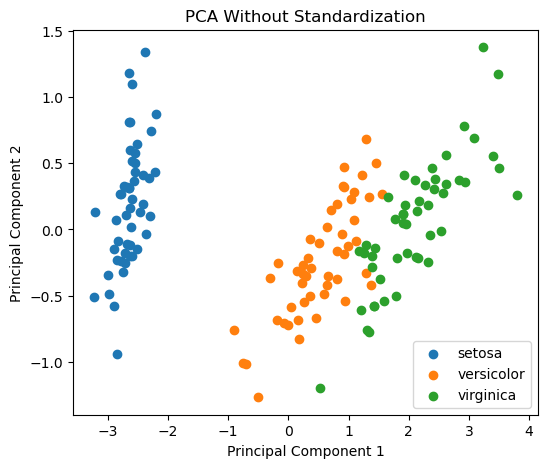

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

for i in range(3):
    plt.scatter(
        X_pca[y==i,0],
        X_pca[y==i,1],
        label=iris.target_names[i]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Without Standardization")
plt.legend()

plt.show()